## Data Preparation and Initial Data Analysis(IDA)

This notebook prepares and explores the raw Guardian dataset.\
The focus is on data cleaning, basic data quality checks, and creating variables for further analysis.

## 1. Load the raw dataset

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv("data/raw/combined_raw.csv")

print("Shape:", df.shape)
print("Columns:", df.columns)

df.head()

Shape: (25142, 7)
Columns: Index(['university', 'id', 'webPublicationDate', 'sectionId', 'sectionName',
       'webTitle', 'wordcount'],
      dtype='object')


,university,id,webPublicationDate,sectionId,sectionName,webTitle,wordcount
0,University of Birmingham,theguardian/2010/jan/03/simonedebeauvoir-oxfor...,2010-01-03T18:36:43Z,global,Global,Elizabeth Fallaize obituary,1007
1,University of Birmingham,education/2010/jan/19/gel-curb-appetite-scient...,2010-01-19T00:05:05Z,education,Education,Food scientists develop appetite-curbing gel,839
2,University of Birmingham,science/2010/jan/25/mary-english-obituary,2010-01-25T18:38:39Z,science,Science,Mary English obituary,931
3,University of Birmingham,science/video/2010/feb/03/good-guys-draw-faste...,2010-02-03T04:50:00Z,science,Science,Video: Why the good guys draw faster in a gunf...,0
4,University of Birmingham,education/2010/feb/06/cv-clinic-jenny-adams,2010-02-06T00:05:03Z,education,Education,CV Clinic,552


### Explanation

The dataset is loaded to inspect its structure, including the number of rows, columns, and variable names.\
This helps us understand what variables are available before cleaning.

## 2. Basic data quality checks

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25142 entries, 0 to 25141
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   university          25142 non-null  object
 1   id                  25142 non-null  object
 2   webPublicationDate  25142 non-null  object
 3   sectionId           25142 non-null  object
 4   sectionName         25142 non-null  object
 5   webTitle            25142 non-null  object
 6   wordcount           25142 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 1.3+ MB


In [30]:
df.isna().sum()

university            0
id                    0
webPublicationDate    0
sectionId             0
sectionName           0
webTitle              0
wordcount             0
dtype: int64

No missing values were detected in the dataset.

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df["wordcount"].describe()

count    25142.000000
mean      1423.447975
std       2471.551938
min          0.000000
25%        599.000000
50%        809.000000
75%       1134.750000
max      42709.000000
Name: wordcount, dtype: float64

## 3. Data cleaning

In [33]:
clean_df = df.copy()

# remove duplicates
clean_df = clean_df.drop_duplicates()

# convert date to datetime
clean_df["webPublicationDate"] = pd.to_datetime(clean_df["webPublicationDate"])

# remove bad dates
clean_df = clean_df.dropna(subset=["webPublicationDate"])

# create time variables
clean_df["year"] = clean_df["webPublicationDate"].dt.year
clean_df["month"] = clean_df["webPublicationDate"].dt.month
clean_df["year_month"] = (
    clean_df["year"].astype(str) + "-" + clean_df["month"].astype(str)
)

# clean wordcount
clean_df["wordcount"] = pd.to_numeric(clean_df["wordcount"])
clean_df = clean_df.dropna(subset=["wordcount"])
clean_df = clean_df[clean_df["wordcount"] >= 0]

print(clean_df.shape)
clean_df.head()

(25142, 10)


,university,id,webPublicationDate,sectionId,sectionName,webTitle,wordcount,year,month,year_month
0,University of Birmingham,theguardian/2010/jan/03/simonedebeauvoir-oxfor...,2010-01-03 18:36:43+00:00,global,Global,Elizabeth Fallaize obituary,1007,2010,1,2010-1
1,University of Birmingham,education/2010/jan/19/gel-curb-appetite-scient...,2010-01-19 00:05:05+00:00,education,Education,Food scientists develop appetite-curbing gel,839,2010,1,2010-1
2,University of Birmingham,science/2010/jan/25/mary-english-obituary,2010-01-25 18:38:39+00:00,science,Science,Mary English obituary,931,2010,1,2010-1
3,University of Birmingham,science/video/2010/feb/03/good-guys-draw-faste...,2010-02-03 04:50:00+00:00,science,Science,Video: Why the good guys draw faster in a gunf...,0,2010,2,2010-2
4,University of Birmingham,education/2010/feb/06/cv-clinic-jenny-adams,2010-02-06 00:05:03+00:00,education,Education,CV Clinic,552,2010,2,2010-2


### Cleaning decisions

- Duplicate rows were removed to avoid double counting.  
- The publication date was converted to datetime format, and rows with invalid dates were removed.  
- New time variables (year, month, year_month) were created for time-based analysis.  
- The wordcount column was cleaned by converting it to numeric format and removing invalid values.  
- University names were already consistent, so no additional cleaning was required.

## 4. Distribution by section

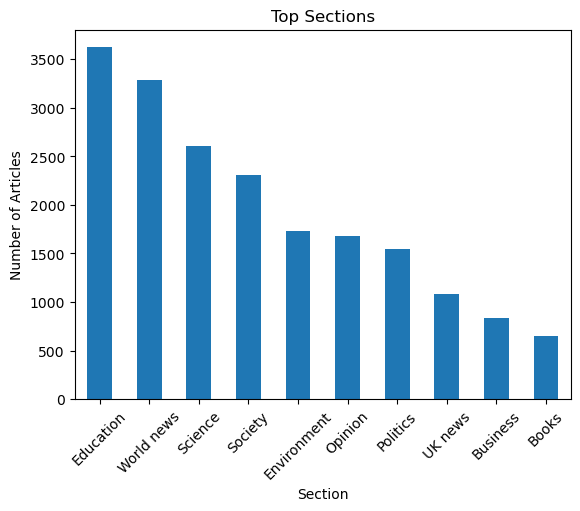

In [34]:
section_counts = clean_df["sectionName"].value_counts().head(10)

plt.figure()
section_counts.plot(kind="bar")

plt.title("Top Sections")
plt.xlabel("Section")
plt.ylabel("Number of Articles")

plt.xticks(rotation=45)
plt.show()

### Interpretation

The chart shows that articles are concentrated in a small number of sections, particularly education, world news, and science.  
This suggests that university-related content is not confined to a single category, but appears across multiple areas of news coverage.

## 5. Articles over time

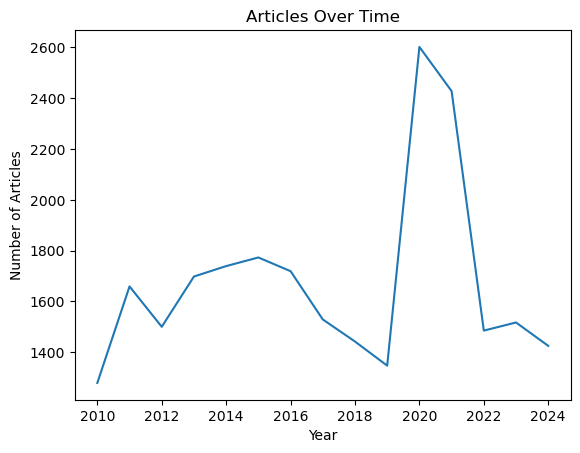

In [35]:
yearly_counts = clean_df.groupby("year").size()

plt.figure()
yearly_counts.plot()

plt.title("Articles Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Articles")

plt.show()

### Interpretation

The number of articles fluctuates over time rather than increasing steadily.\
A noticeable spike appears around 2020–2021, indicating a period of unusually high media coverage of universities.\
After this peak, coverage declines again, suggesting that media attention varies over time and may be influenced by major events.

## 6. Save cleaned dataset

In [36]:
clean_df.to_csv("data/final_dataset.csv", index=False)

## Summary

In this notebook, the dataset was cleaned by removing duplicates, fixing date formats, and handling invalid values.\
New time-based variables were created to support analysis.\
Initial visualisations show that articles are concentrated in a few key sections and that coverage fluctuates over time.\
Overall, the results suggest that media attention on universities varies across topics and time rather than following a consistent trend.